In [1]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support
from astropy.time import Time
import astropy.units as u

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange

import pandas as pd

In [2]:
flares = pd.read_csv("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210101_20260130_version1_python.csv")

In [3]:
flares.columns

Index(['start_UTC', 'end_UTC', 'peak_UTC', '4-10 keV', '10-15 keV',
       '15-25 keV', '25-50 keV', '50-84 keV', 'bkg 4-10 keV', 'bkg 10-15 keV',
       'bkg 15-25 keV', 'bkg 25-50 keV', 'bkg 50-84 keV',
       'bkg_baseline_4-10 keV', 'hpc_x_solo', 'hpc_y_solo', 'hpc_x_earth',
       'hpc_y_earth', 'visible_from_earth', 'hgs_lon', 'hgs_lat', 'hgc_lon',
       'hgc_lat', 'solo_position_lat', 'solo_position_lon',
       'solo_position_AU_distance', 'GOES_class_time_of_flare',
       'GOES_flux_time_of_flare', 'att_in', 'flare_id', 'sidelobes_ratio',
       'goes_estimated_min_class', 'goes_estimated_max_class',
       'goes_estimated_mean_class', 'goes_estimated_min_flux',
       'goes_estimated_max_flux', 'goes_estimated_mean_flux',
       'error_with_imaging', 'cpd_filename'],
      dtype='str')

In [4]:
top100 = flares.sort_values("goes_estimated_mean_flux", ascending=False).head(100)
top100

,start_UTC,end_UTC,peak_UTC,4-10 keV,10-15 keV,15-25 keV,25-50 keV,50-84 keV,bkg 4-10 keV,bkg 10-15 keV,...,flare_id,sidelobes_ratio,goes_estimated_min_class,goes_estimated_max_class,goes_estimated_mean_class,goes_estimated_min_flux,goes_estimated_max_flux,goes_estimated_mean_flux,error_with_imaging,cpd_filename
17678,2024-07-22T23:41:53.133,2024-07-23T01:08:49.142,2024-07-22 23:56:37.134,13491988,344063,442367,86015,25599,271.0,41.0,...,2407222356,0.748790,X7,X30,X14,0.000680,0.002989,0.001404,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024072...
16121,2024-05-20T05:10:08.351,2024-05-20T06:52:32.361,2024-05-20 05:14:40.351,15995187,409599,884735,475135,204799,247.0,37.0,...,2405200514,0.750127,X6,X25,X12,0.000583,0.002534,0.001198,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024052...
12921,2024-02-22T22:09:36.287,2024-02-22T23:31:40.296,2024-02-22 22:30:28.289,15286084,278527,376831,38911,863,303.0,41.0,...,2402222230,0.749670,X5,X21,X10,0.000497,0.002129,0.001014,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024022...
15873,2024-05-15T20:22:27.966,2024-05-15T21:35:47.874,2024-05-15 20:36:47.967,13921122,376831,819199,118783,27647,303.0,41.0,...,2405152036,0.760378,X5,X20,X9,0.000459,0.001956,0.000934,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024051...
8972,2023-07-16T04:22:16.347,2023-07-16T05:48:48.356,2023-07-16 04:33:00.348,8170326,278527,139263,10751,2943,247.0,45.0,...,2307160433,0.749198,X4,X19,X9,0.000400,0.001900,0.000900,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2023071...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19855,2024-09-12T09:27:36.561,2024-09-12T10:42:00.569,2024-09-12 09:37:24.562,3480369,278527,59391,8703,1599,303.0,41.0,...,2409120937,0.795039,M6,X2,X1,0.000055,0.000193,0.000101,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024091...
15986,2024-05-17T12:40:56.029,2024-05-17T12:48:16.030,2024-05-17 12:42:08.029,1376255,204799,21503,799,335,303.0,41.0,...,2405171242,0.767968,M6,X2,X1,0.000055,0.000192,0.000101,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024051...
24906,2025-02-03T03:33:08.170,2025-02-03T04:42:28.177,2025-02-03 03:56:16.172,1114111,221183,34815,2175,335,303.0,41.0,...,2502030356,0.755686,M5,X2,X1,0.000054,0.000190,0.000100,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2025020...
2083,2022-04-30T13:35:03.599,2022-04-30T14:19:47.603,2022-04-30 13:42:03.600,2049455,311295,69631,43007,21503,271.0,49.0,...,2204301342,0.805663,M6,X2,X1,0.000060,0.000200,0.000100,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2022043...


In [5]:
def plot_flare_modified(tstart, tend):
    #getting STIX data
    stix_query = Fido.search(a.Time(tstart, tend), 
                       a.Instrument.stix, 
                       a.stix.DataProduct.ql_lightcurve)

    stix_files = Fido.fetch(stix_query)
    stix_lc = ts.TimeSeries(stix_files, concatenate=True)
    stix_df = stix_lc.to_dataframe()

    tstart_obj = parse_time(tstart)

    tend_obj = parse_time(tend)
    
    stix_df = stix_df.truncate(tstart_obj.datetime, tend_obj.datetime)

    stix_df.index = parse_time(stix_df.index).datetime

    #plotting lightcurves
    stix_df.plot(ax=ax, y='25-50 keV', label='25-50 keV', legend=None)
    stix_df.plot(ax=ax, y='50-84 keV', label='50-84 keV', legend=None)
        
    #legend
    # lines1, labels1 = ax.get_legend_handles_labels()
    
    # ax.legend(lines1 + lines2, loc='upper right', fontsize='small')
    # plt.title(f"{tstart_obj.datetime.year}-{tstart_obj.datetime.month}")

In [6]:
top100['start_UTC'].loc[17678]

'2024-07-22T23:41:53.133'

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

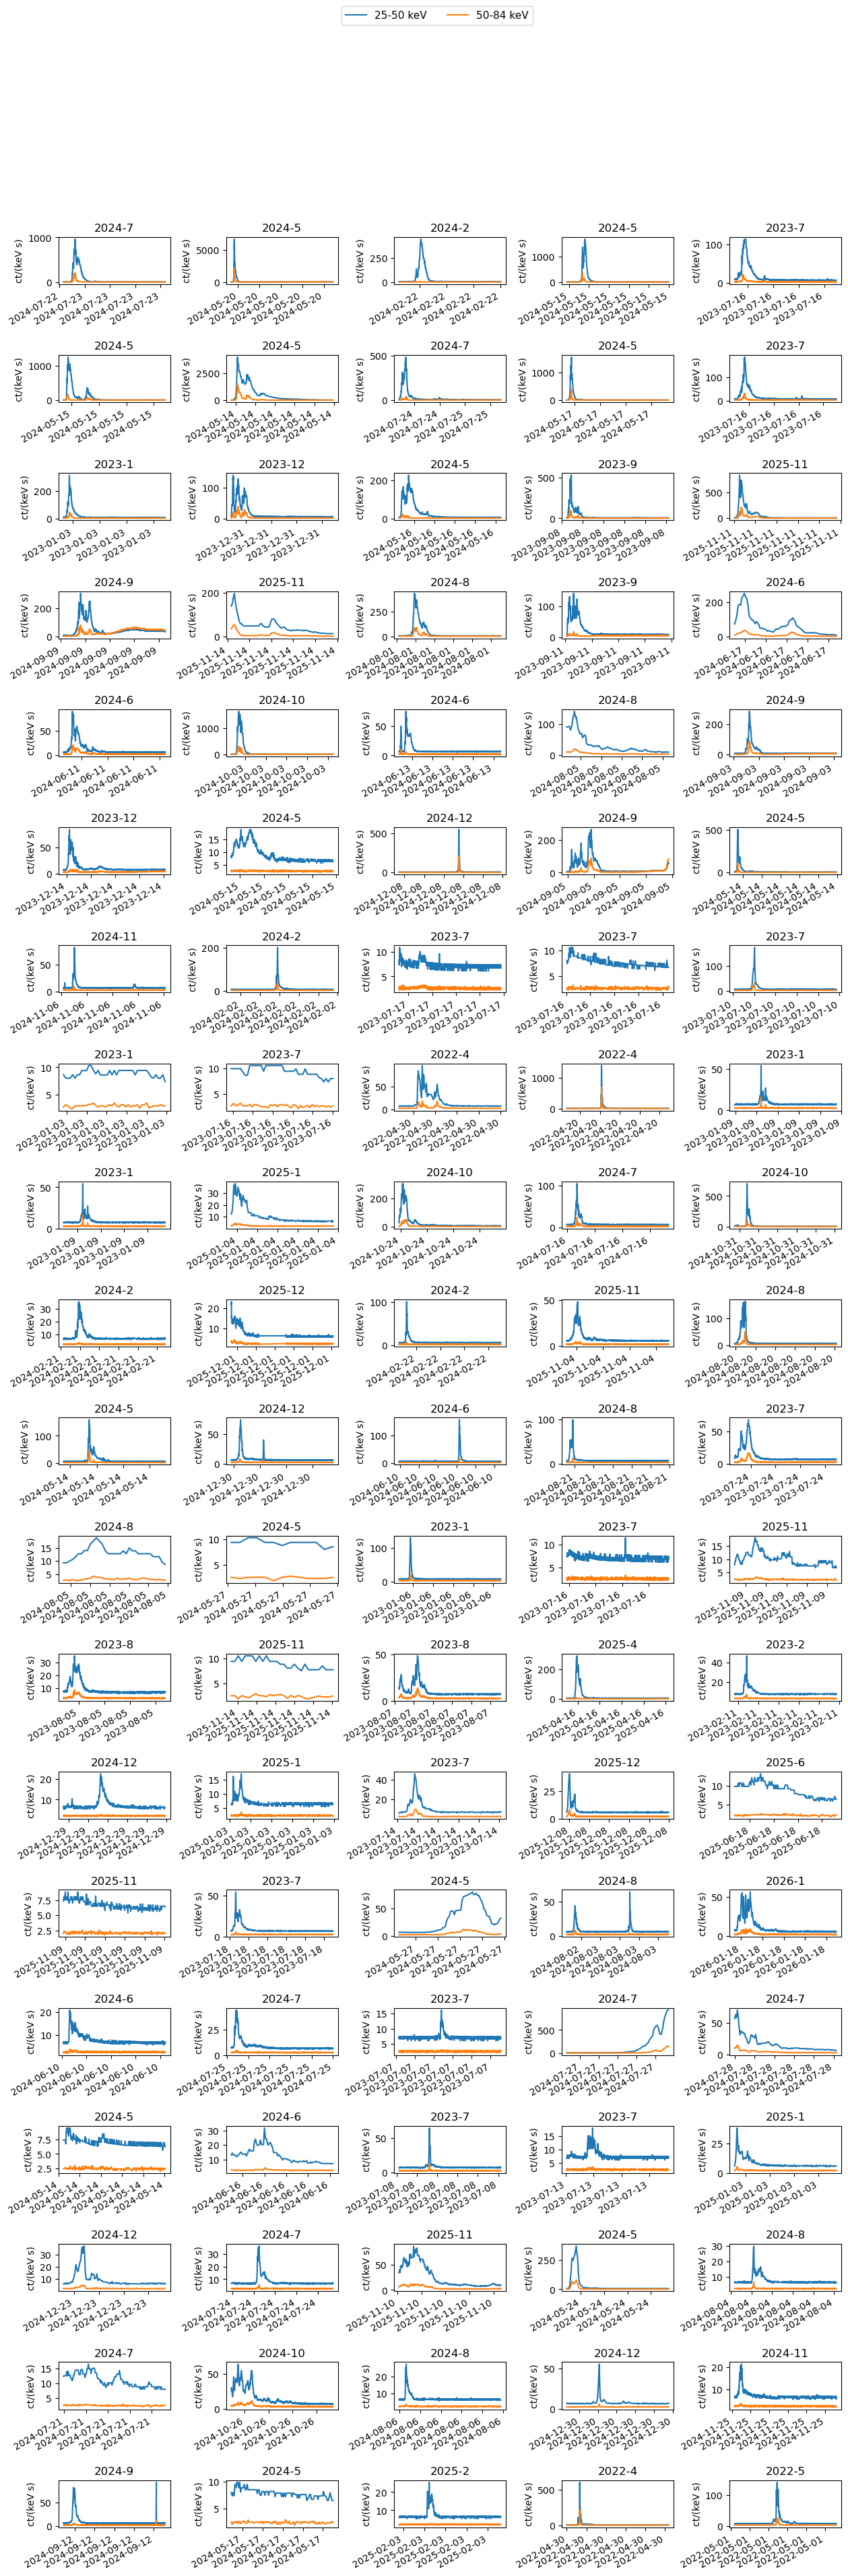

In [51]:

# ax.set_yscale('linear')
# ax.set_ylabel('ct/(keV s)')


fig, axes = plt.subplots(nrows=20, ncols=5, figsize=(15, 50))
axes = axes.flatten()
i=0
for ind in top100.index:
    ax=axes[i]
    plot_flare_modified(top100['start_UTC'].loc[ind], top100['end_UTC'].loc[ind])
    ax.set_ylabel('ct/(keV s)')
    ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
    i+=1

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=11)
fig.subplots_adjust(hspace=1.5)
fig.subplots_adjust(wspace=0.5)

plt.show()
fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/top_100_flares_quicklook_data.png", bbox_inches='tight')

In [8]:
top100['flare_id']

17678    2407222356
16121    2405200514
12921    2402222230
15873    2405152036
8972     2307160433
            ...    
19855    2409120937
15986    2405171242
24906    2502030356
2083     2204301342
2130     2205010814
Name: flare_id, Length: 100, dtype: int64

In [9]:
flare1 = top100.loc[17678]
print(flare1['start_UTC'], flare1['end_UTC'])

2024-07-22T23:41:53.133 2024-07-23T01:08:49.142


In [10]:
flare1['flare_id']

np.int64(2407222356)

In [11]:
flare1['cpd_filename']

'./pixel_data/solo_L1_stix-sci-xray-cpd_20240722T232050-20240723T001432_V02_2407227814-56169.fits'

In [63]:
sci_query = Fido.search(a.Time(flare1['start_UTC'], flare1['end_UTC']), 
                        a.Instrument.stix,
                        a.stix.DataType.sci)
sci_query['stix'].filter_for_latest_version()
sci_query

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2024-07-22T22:59:59.000,2024-07-23T05:00:03.000,STIX,L1,SCI,sci-xray-cpd,V02,2407226158
2024-07-22T23:20:50.000,2024-07-23T00:14:32.000,STIX,L1,SCI,sci-xray-cpd,V02,2407227814
2024-07-22T21:25:14.000,2024-07-23T03:29:59.000,STIX,L1,SCI,sci-xray-spec,V04,2407221990
2024-07-23T00:14:17.000,2024-07-23T01:19:30.000,STIX,L1,SCI,sci-xray-cpd,V02,2407236589


In [13]:
sci_files = Fido.fetch(sci_query[0][[1,2]])
sci_files = sorted(sci_files)
sci_files

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

['C:\\Users\\derva\\sunpy\\data\\solo_L1_stix-sci-xray-cpd_20240722T232050-20240723T001432_V02_2407227814-56169.fits',
 'C:\\Users\\derva\\sunpy\\data\\solo_L1_stix-sci-xray-spec_20240722T212514-20240723T032959_V04_2407221990-58981.fits']

In [14]:
from stixpy.product import Product
cpd1_1 = Product(sci_files[0])
cpd1_2 = Product(sci_files[1])

In [15]:
cpd1_1.energies

channel,e_low,e_high
,keV,keV
uint8,float32,float32
0,4.0,5.0
1,5.0,6.0
2,6.0,7.0
3,7.0,8.0
4,8.0,9.0
5,9.0,10.0
6,10.0,11.0
7,11.0,12.0


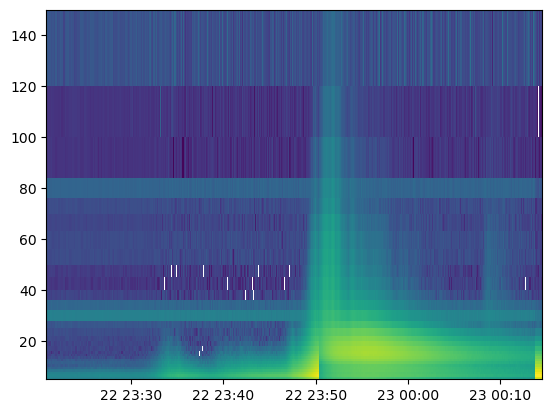

In [16]:
cpd1_1.plot_spectrogram()

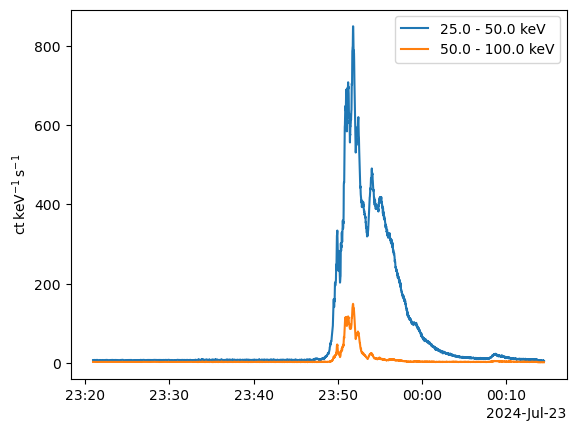

In [17]:
cpd1_1.plot_timeseries(energy_indices=[[16, 21], [22, 27]])
plt.legend()
plt.yscale('linear')

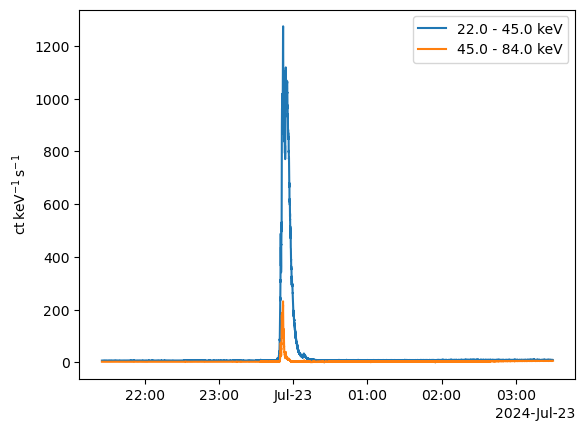

In [18]:
cpd1_2.plot_timeseries(energy_indices=[[16, 21], [22, 27]])
plt.legend()
plt.yscale('linear')

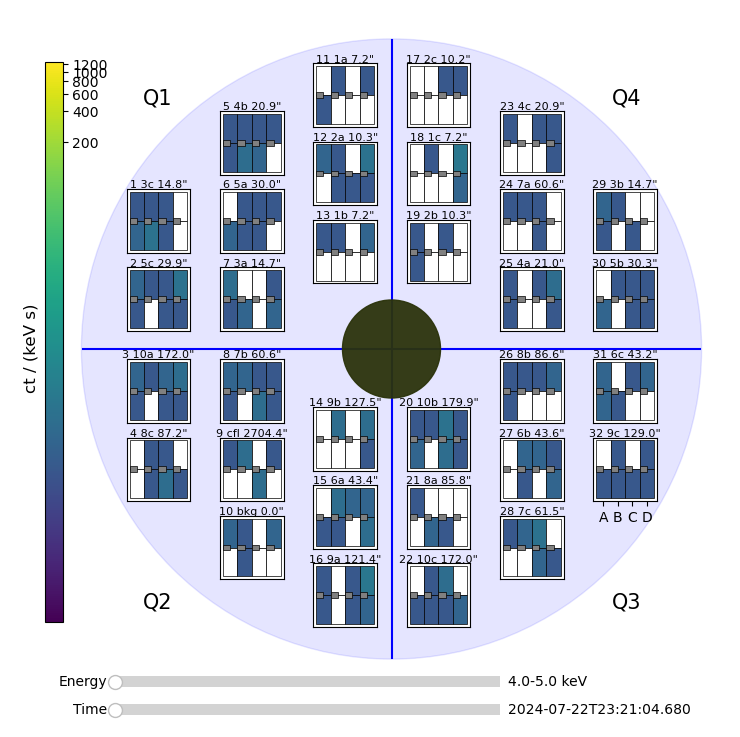

In [22]:
cpd1_1.plot_pixels()

In [23]:
cpd1_2.energies["e_low"]>6*u.keV

array([False, False, False, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [24]:
flare2 = top100.loc[16121]
print(flare2['start_UTC'], flare2['end_UTC'])

2024-05-20T05:10:08.351 2024-05-20T06:52:32.361


In [61]:
sci_query = Fido.search(a.Time(flare2['start_UTC'], flare2['end_UTC']), 
                        a.Instrument.stix,
                        a.stix.DataType.sci)
sci_query['stix'].filter_for_latest_version()
sci_query

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2024-05-20T04:45:00.000,2024-05-20T10:45:00.000,STIX,L1,SCI,sci-xray-cpd,V02,2405209951
2024-05-20T04:57:02.000,2024-05-20T05:38:05.000,STIX,L1,SCI,sci-xray-cpd,V02,2405203899
2024-05-20T05:07:11.000,2024-05-20T05:24:48.000,STIX,L1,SCI,sci-xray-cpd,V02,2405207131
2024-05-20T02:29:59.000,2024-05-20T08:34:59.000,STIX,L1,SCI,sci-xray-spec,V04,2405209781


In [26]:
flare2['cpd_filename']

'./pixel_data/solo_L1_stix-sci-xray-cpd_20240520T044500-20240520T104500_V02_2405209951-50924.fits'

In [27]:
flare2['flare_id']

np.int64(2405200514)

In [28]:
sci_files = Fido.fetch(sci_query[0][0])
sci_files = sorted(sci_files)
sci_files

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

['C:\\Users\\derva\\sunpy\\data\\solo_L1_stix-sci-xray-cpd_20240520T044500-20240520T104500_V02_2405209951-50924.fits']

In [68]:
cpd2 = Product(sci_files)
cpd2

CompressedPixelData   <sunpy.time.timerange.TimeRange object at 0x21676061d90>
    Start: 2024-05-15 20:15:54
    End:   2024-05-15 21:43:32
    Center:2024-05-15 20:59:43
    Duration:0.060857638888888954 days or
           1.460583333333335 hours or
           87.63500000000009 minutes or
           5258.100000000006 seconds
    DetectorMasks
    [0...261]: [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]

    PixelMasks
    [0...261]: [['1' '1' '1' '1' '1' '1' '1' '1' '0' '0' '0' '0']]

    EnergyEdgeMasks
    [0]: [_,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,_,_,_,_,_,_,_,_,_,_,_,_,_,_]

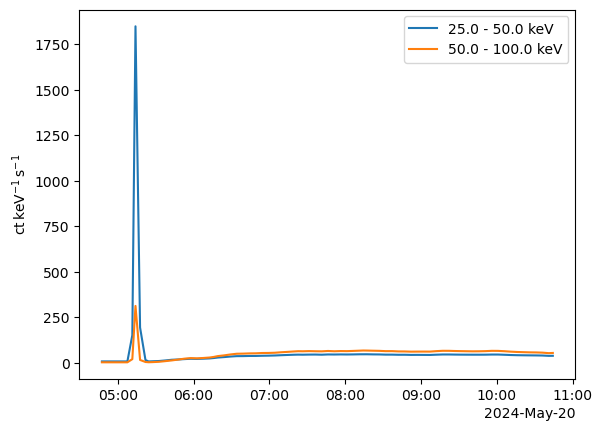

In [30]:
cpd2.plot_timeseries(energy_indices=[[16, 21], [22, 27]])
plt.legend()
plt.yscale('linear')

In [31]:
energy_ranges = [(25.0*u.keV, 50*u.keV), (50.0*u.keV, 100*u.keV)]

In [32]:
def get_energy_indices(qtable, ranges):
    energy_indices = []
    for e_min, e_max in ranges:
        start_index = np.where(qtable["e_low"] >= e_min)[0][0]
        end_index = np.where(qtable["e_high"] <= e_max)[0][-1]
        energy_indices.append([int(start_index), int(end_index)])
    return energy_indices
    
def get_stix_df(stix_sci, energy_ranges):
    # energy_ranges = [(5.0*u.keV, 10*u.keV),
    #                  (10.0*u.keV, 15*u.keV),
    #                  (15.0*u.keV, 22.0*u.keV), 
    #                  (22.0*u.keV, 45.0*u.keV),]
    
    energy_indices = get_energy_indices(stix_sci.energies, energy_ranges)
    counts, errors, times, timedeltas, energies = stix_sci.get_data(detector_indices=[[0, 31]],
                                                                    pixel_indices=[[0, 11]],
                                                                    energy_indices=energy_indices,)
    counts = counts.to(u.ct / u.s / u.keV)
    errors = errors.to(u.ct / u.s / u.keV)
    timedeltas = timedeltas.to(u.s)
    
    times = times
    
    energy_columns = [f"{e['e_low']}-{e['e_high']}" for e in energies]
    
    counts_reshaped = counts[:, 0, 0, :]
    
    counts_df = pd.DataFrame(counts_reshaped, index=times.datetime, columns=energy_columns)
    return counts_df

In [74]:
cpd1_2.energies['e_low'][len(cpd1_2.energies['e_low'])-1]

<Quantity 150. keV>

In [71]:
largeflare_sci_df = get_stix_df(cpd1_2, energy_ranges)
largeflare_sci_df

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
2024-07-22 21:25:24.318,6.036000,1.762000
2024-07-22 21:25:44.318,6.108000,1.826000
2024-07-22 21:26:04.318,6.476000,1.650000
2024-07-22 21:26:24.318,6.648000,1.670000
2024-07-22 21:26:44.318,6.652000,1.682000
...,...,...
2024-07-23 03:29:38.668,8.355556,5.111111
2024-07-23 03:29:43.318,7.683333,5.025000
2024-07-23 03:29:48.068,8.476596,4.791489
2024-07-23 03:29:52.768,8.765957,5.336170


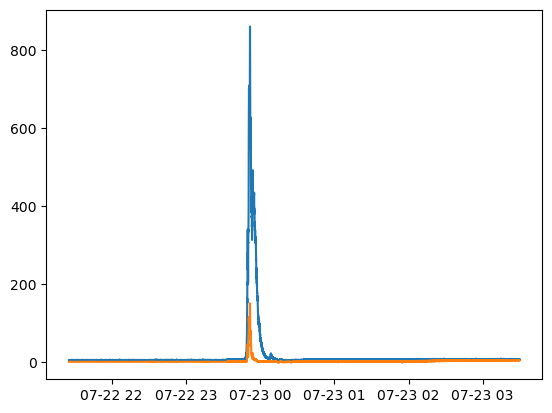

In [34]:
plt.plot(largeflare_sci_df.index, largeflare_sci_df['25.0 keV-50.0 keV'])
plt.plot(largeflare_sci_df.index, largeflare_sci_df['50.0 keV-100.0 keV'])

In [35]:
len(largeflare_sci_df.columns)

2

In [112]:
def plot_flare_modified_sci(sci_df, flare_start=None, flare_end=None):
    if flare_start!=None and flare_end!=None:
        flare_start_obj = parse_time(flare_start)
    
        flare_end_obj = parse_time(flare_end)
        
        plot_df = sci_df.truncate(flare_start_obj.datetime, flare_end_obj.datetime)
    else:
        plot_df = sci_df.copy()
        
    plot_df.index = parse_time(plot_df.index).datetime

    #plotting lightcurves
    fig, ax = plt.subplots()
    ax.set_yscale('linear')
    ax.set_ylabel('ct/(keV s)')
    
    for n in range(len(plot_df.columns)):
        ax.plot(ax=ax, y=plot_df.columns[n], label=plot_df.columns[n], legend=None)

    lines, labels = ax.get_legend_handles_labels()
    ax.legend(lines, labels, loc='upper right', fontsize='small')
    if flare_start!=None and flare_end!=None:
        plt.title(f"{flare_start_obj.datetime.year}-{flare_end_obj.datetime.month}")
        

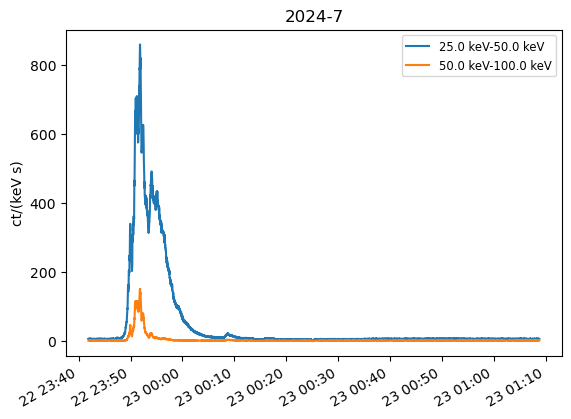

In [37]:
plot_flare_modified_sci(largeflare_sci_df, flare1['start_UTC'], flare1['end_UTC'])

In [124]:
df_list=[]
indices=[]
for ind in top100.index:
    sci_query = Fido.search(a.Time(top100['start_UTC'].loc[ind], 
                                   top100['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci)
    sci_query['stix'].filter_for_latest_version()

    start = parse_time(top100['start_UTC'].loc[ind]).datetime
    end = parse_time(top100['end_UTC'].loc[ind]).datetime

    data=False
    badrange=False
    for n in range(len(sci_query[0])):
        if sci_query[0][n][0].datetime<=start and sci_query[0][n][1].datetime>=end:
            sci_files = Fido.fetch(sci_query[0][n])
            sci_data = Product(sci_files)
            data=True
            if sci_data.energies["e_high"][len(sci_data.energies["e_high"])-1]<100*u.keV or sci_data.energies["e_low"][0]>25*u.keV:
                badrange=True
        if data and not badrange:
            sci_df = get_stix_df(sci_data, energy_ranges)
            df_list.append(sci_df)
            indices.append(ind)
            break
    
    
    
        

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [125]:
len(df_list)

60

In [126]:
len(indices)

60

In [141]:
listind100 = top100.index.tolist()
diff = set(listind100)-set(indices)
diff

{6201,
 8717,
 8745,
 10252,
 12890,
 12903,
 15754,
 15798,
 15799,
 15856,
 15873,
 16441,
 16442,
 16647,
 16662,
 16837,
 16865,
 17486,
 17633,
 17750,
 18238,
 18320,
 19855,
 21278,
 22177,
 22261,
 22548,
 22906,
 23889,
 24133,
 24215,
 24342,
 24354,
 24906,
 26858,
 30475,
 30476,
 30637,
 30638,
 31028}

In [147]:
def plot_flare_modified_sci_multiple(sci_df):

    start = parse_time(top100['start_UTC'].loc[indices[i]]).datetime

    end = parse_time(top100['end_UTC'].loc[indices[i]]).datetime
    
    plot_df = sci_df.truncate(start, end)
        
    plot_df.index = parse_time(plot_df.index).datetime
    
    for n in range(len(plot_df.columns)):
        ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])

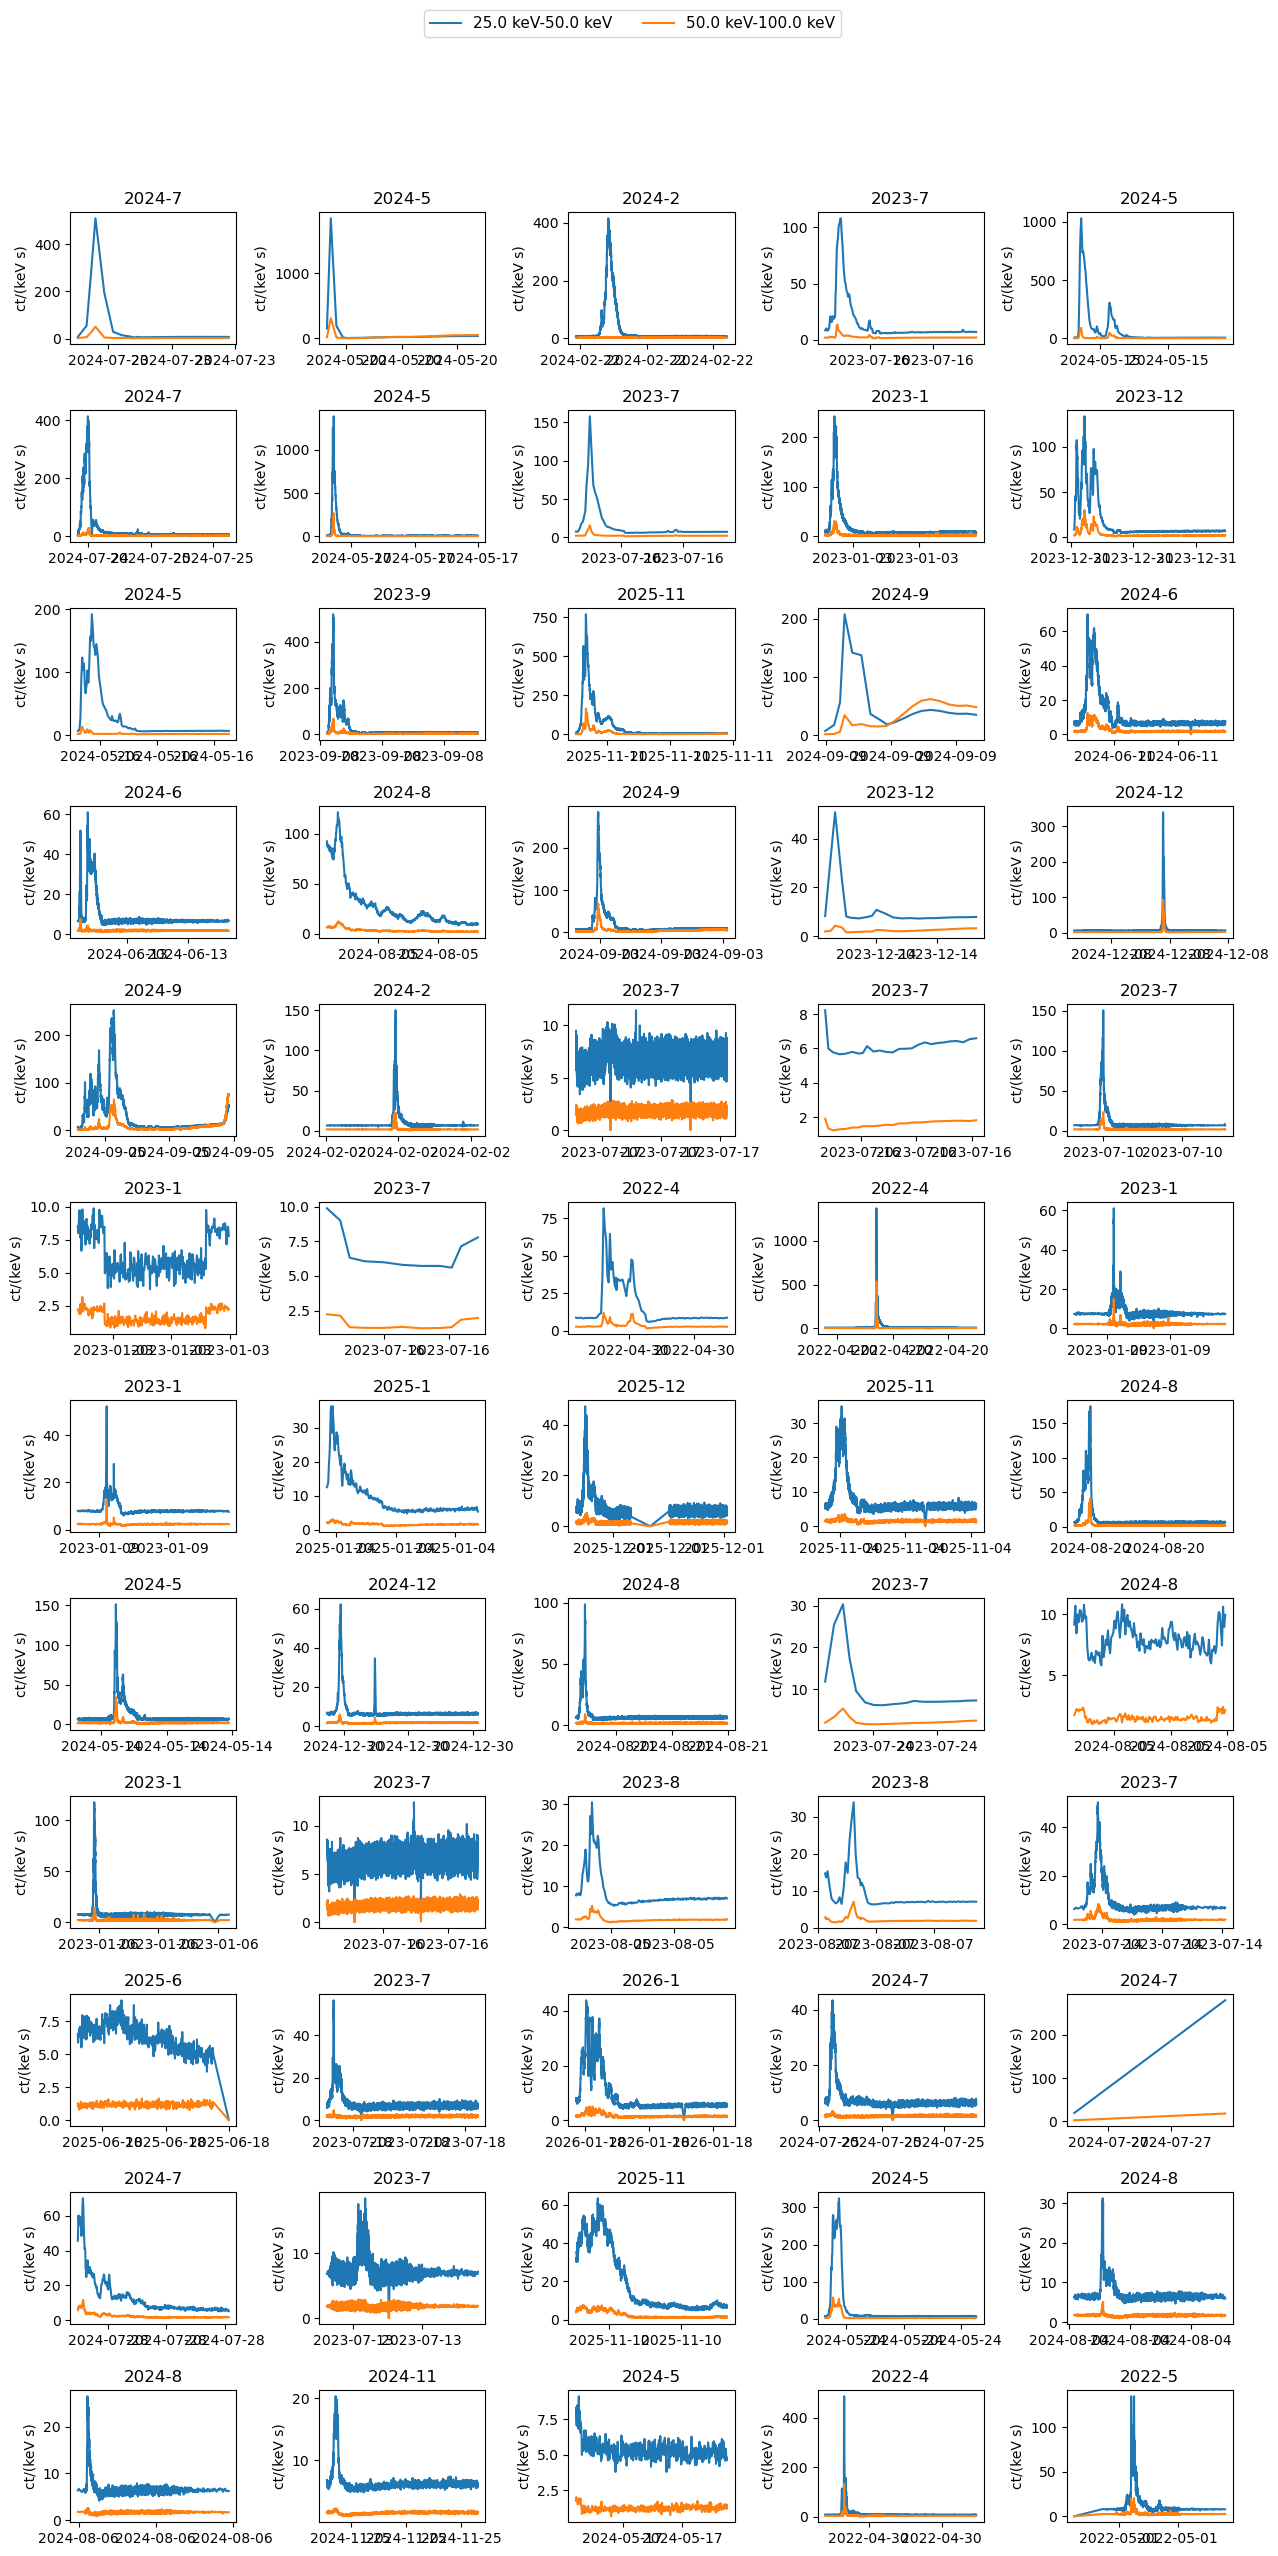

In [148]:
fig, axes = plt.subplots(nrows=12, ncols=5, figsize=(15, 30))
axes = axes.flatten()
i=0
for df in df_list:
    ax=axes[i]
    plot_flare_modified_sci_multiple(df)
    ax.set_ylabel('ct/(keV s)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.set_title(f"{parse_time(top100['start_UTC'].loc[indices[i]]).datetime.year}-{parse_time(top100['start_UTC'].loc[indices[i]]).datetime.month}")
    i+=1

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=11)
fig.subplots_adjust(hspace=0.5)
fig.subplots_adjust(wspace=0.5)

plt.show()